# Does AI Reward High-Skill Work? Evidence from US Labour Markets

Artificial intelligence is often discussed as a threat to jobs, but a more useful question is whether AI is changing inequality across occupations. Some occupations appear highly exposed to AI because many of their tasks overlap with current AI capabilities. At the same time, these occupations are often relatively well paid and professionally skilled. This raises an important question: does AI exposure itself reward workers, or does it simply reflect the fact that AI is concentrated in high-skill occupations?

This project studies the relationship between occupation-level AI exposure, pay, employment, and labour demand in the United States. I combine an AI exposure index with labour market data from the Bureau of Labor Statistics and education information from the National Employment Matrix. The analysis is cross-sectional and focuses on association rather than causality.

The central finding is that AI exposure is strongly associated with higher wages in raw comparisons, but this relationship largely disappears once occupational skill is controlled for. By contrast, AI exposure remains positively associated with employment levels, while labour demand shows no robust relationship. Overall, the evidence suggests that AI is concentrated in high-skill, high-paying occupations, but does not independently increase wage returns once skill is taken into account.

## Research Question

This project asks three related questions.

1. Are occupations with higher AI exposure better paid?
2. Are occupations with higher AI exposure larger or smaller in employment?
3. Is labour demand stronger in occupations with higher AI exposure?

A further question is whether any observed wage premium remains once occupational skill is taken into account.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

df = pd.read_csv("data/processed/final_analysis_data.csv")
results = pd.read_csv("output/tables/regression_results.csv")


## Data

The analysis combines five occupation-level inputs.

First, the AI Occupation Exposure index provides a measure of how exposed occupational tasks are to current AI capabilities. Higher values indicate greater task exposure.

Second, BLS Occupational Employment and Wage Statistics provide employment levels and median annual pay by occupation.

Third, BLS Employment Projections provide average annual occupational openings, which I use as a proxy for labour demand.

Fourth, BLS education assignments provide typical education needed for entry. I convert this into an ordinal skill measure.

Finally, occupations are harmonised using SOC occupation codes so that the datasets can be merged consistently.

The final analysis dataset contains 668 occupations after cleaning and merging.

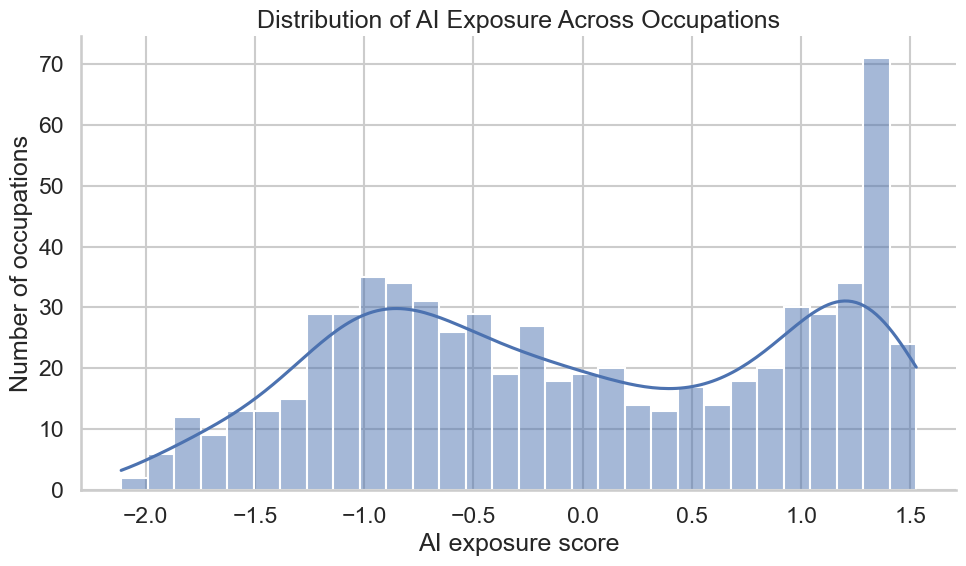

In [5]:
plt.figure()
sns.histplot(df["ai_exposure"], bins=30, kde=True)
plt.title("Distribution of AI Exposure Across Occupations")
plt.xlabel("AI exposure score")
plt.ylabel("Number of occupations")
plt.tight_layout()
plt.show()

AI exposure varies substantially across occupations. Some jobs have very low exposure, while others are strongly exposed. This variation is important because it allows meaningful comparisons across occupations rather than relying on a narrow set of highly technical jobs.

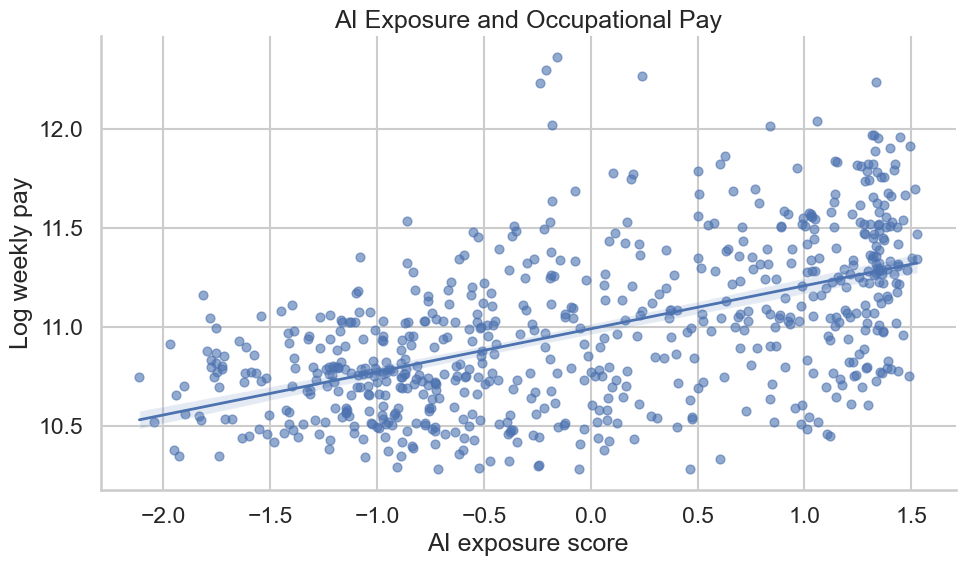

In [7]:
plt.figure()
sns.regplot(
    x="ai_exposure",
    y="log_pay",
    data=df,
    scatter_kws={"alpha": 0.6, "s": 40},
    line_kws={"linewidth": 2}
)
plt.title("AI Exposure and Occupational Pay")
plt.xlabel("AI exposure score")
plt.ylabel("Log weekly pay")
plt.tight_layout()
plt.show()

The raw data show a strong positive relationship between AI exposure and pay. Occupations with greater AI exposure tend to be better paid. On its own, this might suggest that AI complements workers in more exposed occupations. However, this raw pattern may also reflect occupational sorting, since many highly exposed jobs are also highly skilled.

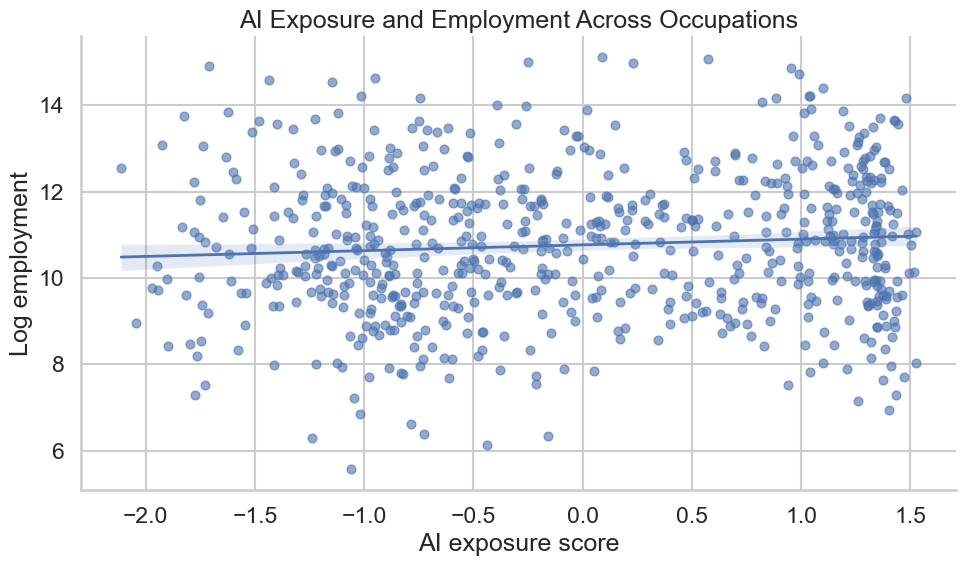

In [9]:
plt.figure()
sns.regplot(
    x="ai_exposure",
    y="log_employment",
    data=df,
    scatter_kws={"alpha": 0.6, "s": 40},
    line_kws={"linewidth": 2}
)
plt.title("AI Exposure and Employment Across Occupations")
plt.xlabel("AI exposure score")
plt.ylabel("Log employment")
plt.tight_layout()
plt.show()

AI exposure is also positively associated with employment levels. This is already a useful result because it suggests that highly exposed occupations are not simply disappearing occupations. Instead, AI appears to be concentrated in roles that are relatively large in the labour market.

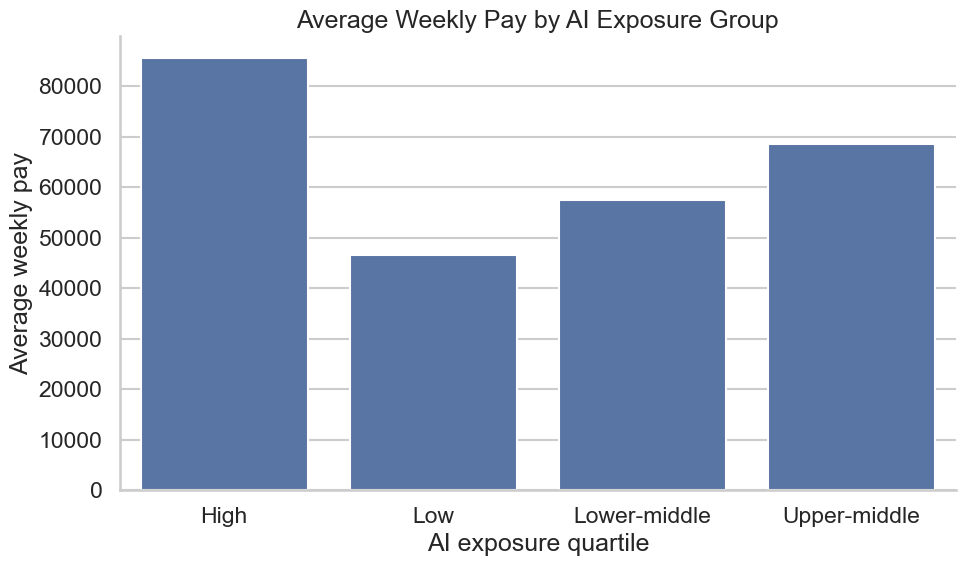

In [11]:
quartile_summary = (
    df.groupby("exposure_quantile", observed=False)["weekly_pay"]
    .mean()
    .reset_index()
)

plt.figure()
sns.barplot(data=quartile_summary, x="exposure_quantile", y="weekly_pay")
plt.title("Average Weekly Pay by AI Exposure Group")
plt.xlabel("AI exposure quartile")
plt.ylabel("Average weekly pay")
plt.tight_layout()
plt.show()

Average pay rises across AI exposure groups. This reinforces the raw positive association between AI exposure and wages. Still, this figure does not tell us whether AI exposure itself matters once skill is taken into account.

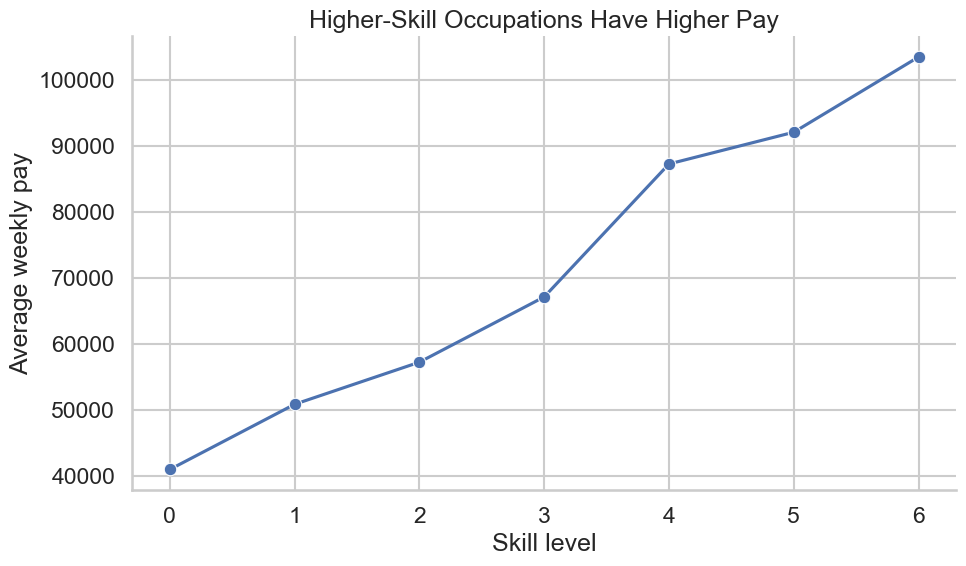

In [13]:
skill_summary = (
    df.groupby("skill")["weekly_pay"]
    .mean()
    .reset_index()
)

plt.figure()
sns.lineplot(data=skill_summary, x="skill", y="weekly_pay", marker="o")
plt.title("Higher-Skill Occupations Have Higher Pay")
plt.xlabel("Skill level")
plt.ylabel("Average weekly pay")
plt.tight_layout()
plt.show()

Pay increases strongly with occupational skill. This is important because if AI exposure is concentrated in occupations with high education requirements, then the apparent AI wage premium may really be a skill premium.

## Regression Results

To test this more formally, I estimate occupation-level regressions for wages, employment, and labour demand. The baseline specification includes AI exposure only. I then add the skill measure, and finally an interaction between AI exposure and skill.

The wage results are the most revealing. In the baseline model, AI exposure is strongly positively associated with pay. However, once skill is included, the AI coefficient falls sharply. This indicates that much of the baseline wage relationship reflects the fact that high-AI occupations are also high-skill occupations.

Employment results tell a different story. AI exposure remains positively associated with employment levels even after controlling for skill. This suggests that highly exposed occupations are not just high paying, but also relatively large.

For labour demand, measured using average annual occupational openings, there is no robust relationship with AI exposure once controls are included.

In [16]:
wage_results = results[results["outcome"] == "log_pay"].copy()
employment_results = results[results["outcome"] == "log_employment"].copy()
demand_results = results[results["outcome"] == "advert_intensity"].copy()

wage_summary = wage_results[
    wage_results["term"].isin(["ai_exposure", "skill", "ai_skill_interaction"])
][["model", "term", "coef", "p_value"]].copy()

wage_summary["coef"] = wage_summary["coef"].round(4)
wage_summary["p_value"] = wage_summary["p_value"].round(3)
wage_summary.columns = ["Model", "Term", "Coefficient", "P-Value"]
wage_summary.style.format({"Coefficient": "{:.4f}", "P-Value": "{:.3f}"}) \
    .set_caption("Table 1: Wage Regression Results") \
    .hide(axis="index")

wage_summary = wage_results[
    wage_results["term"].isin(["ai_exposure", "skill", "ai_skill_interaction"])
][["model", "term", "coef", "p_value"]].copy()

wage_summary["coef"] = wage_summary["coef"].round(4)
wage_summary["p_value"] = wage_summary["p_value"].round(3)
wage_summary.columns = ["Model", "Term", "Coefficient", "P-Value"]
wage_summary.style.format({"Coefficient": "{:.4f}", "P-Value": "{:.3f}"}) \
    .set_caption("Table 1: Wage Regression Results") \
    .hide(axis="index")

Model,Term,Coefficient,P-Value
baseline_full,ai_exposure,0.2174,0.000
with_skill_full,ai_exposure,0.0287,0.056
with_skill_full,skill,0.1458,0.000
with_interaction_full,ai_exposure,0.0301,0.078
with_interaction_full,skill,0.1464,0.000
with_interaction_full,ai_skill_interaction,-0.0009,0.914
baseline_trimmed,ai_exposure,0.1854,0.000
with_skill_trimmed,ai_exposure,0.0306,0.021
with_skill_trimmed,skill,0.1232,0.000
with_interaction_trimmed,ai_exposure,0.0258,0.120


The wage regressions show a clear pattern.

In the baseline specification, AI exposure has a large positive coefficient. Once skill is added, the coefficient becomes much smaller. When the interaction term is included, neither the direct AI effect nor the interaction is statistically meaningful. This means there is no strong evidence that AI exposure raises wages differently across skill groups. Instead, the main explanation is that highly exposed occupations are already highly skilled.

In [18]:
employment_summary = employment_results[
    employment_results["term"].isin(["ai_exposure", "skill", "ai_skill_interaction"])
][["model", "term", "coef", "p_value"]].copy()

employment_summary["coef"] = employment_summary["coef"].round(4)
employment_summary["p_value"] = employment_summary["p_value"].round(3)
employment_summary.columns = ["Model", "Term", "Coefficient", "P-Value"]
employment_summary.style.format({"Coefficient": "{:.4f}", "P-Value": "{:.3f}"}) \
    .set_caption("Table 2: Employment Regression Results") \
    .hide(axis="index")


Model,Term,Coefficient,P-Value
baseline_full,ai_exposure,0.1337,0.041
with_skill_full,ai_exposure,0.4728,0.000
with_skill_full,skill,-0.2620,0.000
with_interaction_full,ai_exposure,0.5423,0.000
with_interaction_full,skill,-0.2357,0.000
with_interaction_full,ai_skill_interaction,-0.0452,0.334
baseline_trimmed,ai_exposure,0.1313,0.050
with_skill_trimmed,ai_exposure,0.4654,0.000
with_skill_trimmed,skill,-0.2660,0.000
with_interaction_trimmed,ai_exposure,0.5248,0.000


Employment results are more stable. AI exposure remains positively associated with employment levels after skill is included. At the same time, skill itself is negatively associated with employment size, which is plausible because high-skill occupations are often fewer in number. This means AI exposure appears related to occupational scale in a way that is not simply reducible to education requirements.

In [20]:
demand_summary = demand_results[
    demand_results["term"].isin(["ai_exposure", "skill", "ai_skill_interaction"])
][["model", "term", "coef", "p_value"]].copy()

demand_summary["coef"] = demand_summary["coef"].round(6)
demand_summary["p_value"] = demand_summary["p_value"].round(3)
demand_summary.columns = ["Model", "Term", "Coefficient", "P-Value"]

styled = demand_summary.style.format({"Coefficient": "{:.2e}", "P-Value": "{:.3f}"})
styled = styled.set_caption("Table 3: Labour Demand Regression Results")
styled = styled.hide(axis="index")
styled


IndentationError: unexpected indent (2075939200.py, line 9)

## Robustness Checks

I use two robustness checks for the wage results.

First, I trim the top 5% of occupations by weekly pay to test whether the main findings are driven by a small number of extremely highly paid occupations.

Second, I estimate median regressions. These are less sensitive to skewness in the wage distribution and therefore provide a useful check on whether the baseline OLS results are driven by the upper tail.

In [ ]:
robust_compare = results[
    (results["outcome"] == "log_pay") &
    (results["term"] == "ai_exposure") &
    (results["model"].isin([
        "baseline_full", "with_skill_full",
        "baseline_trimmed", "with_skill_trimmed",
        "baseline_median", "with_skill_median"
    ]))
][["model", "coef", "p_value"]].copy()

robust_compare["coef"] = robust_compare["coef"].round(4)
robust_compare["p_value"] = robust_compare["p_value"].round(3)
robust_compare.columns = ["Specification", "AI Exposure Coefficient", "P-Value"]
robust_compare.style.format({"AI Exposure Coefficient": "{:.4f}", "P-Value": "{:.3f}"}) \
    .set_caption("Table 2: Robustness Checks — AI Exposure Coefficient on Log Wages") \
    .hide(axis="index")


The robustness checks strengthen the interpretation rather than weaken it.

Trimming the top 5% of wages leaves the main pattern intact. The baseline AI coefficient remains positive and large, and the controlled specification still shows that the coefficient falls sharply once skill is included. This indicates that the headline result is not driven by a small number of very highly paid occupations.

Median regression pushes the interpretation even further. In the baseline specification, AI exposure remains positively associated with pay. But once skill is controlled for, the AI effect becomes statistically insignificant and close to zero. This strongly suggests that the apparent AI wage premium is mainly a reflection of occupational skill composition rather than an independent return to AI exposure.

## Interpretation

Taken together, the findings suggest that AI is concentrated in occupations that are already advantaged. These occupations tend to require more education, pay more, and in many cases employ large numbers of workers. However, the wage premium associated with AI exposure is mostly explained by skill rather than by AI exposure itself.

This matters for the economic interpretation. The results support a skill-biased allocation story more than a pure complementarity story. AI appears to be associated with high-skill work, but the evidence does not show that AI independently increases wage returns once occupational skill is taken into account.

## Limitations

This project has several limitations.

First, the analysis is cross-sectional and does not identify causal effects. The results should therefore be interpreted as associations.

Second, occupation-level averages hide substantial variation within occupations. Two workers in the same occupation may use AI very differently.

Third, the AI exposure measure captures task exposure rather than realised AI adoption. Exposure does not necessarily imply that employers have already adopted these tools at scale.

Fourth, labour demand is proxied using projected occupational openings rather than real-time job postings. This is a reasonable measure, but it captures medium-run demand rather than short-run hiring dynamics.

## Machine Learning Evidence

To complement the regression analysis, I train a Random Forest model to predict log wages 
from occupation characteristics. Unlike OLS regression, Random Forests can capture 
nonlinear relationships and interactions between features without requiring them to be 
specified in advance.

The cross-validated R² is near zero, which confirms that occupation-level wages are 
difficult to predict purely from these features in a small cross-sectional sample of 
670 occupations. However, the feature importance scores reveal which variables the model 
relies on most, providing a useful robustness check on the regression findings.



In [ ]:
fi = pd.read_csv("output/tables/ml_feature_importance.csv")
fi = fi.sort_values("importance", ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(fi["feature_label"], fi["importance"], color="#2196F3", edgecolor="white")
ax.bar_label(bars, fmt="%.3f", padding=3, fontsize=9)
ax.spines[["top", "right"]].set_visible(False)
ax.set_title("What Predicts Wages? Random Forest Feature Importance",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Feature Importance (Mean Decrease in Impurity)", fontsize=11)
ax.set_xlim(0, fi["importance"].max() * 1.2)
plt.tight_layout()
plt.show()

Education level emerges as the most important predictor of wages, followed by AI exposure 
itself. This is consistent with the regression findings: skill is the dominant driver of 
wages, but AI exposure carries independent information even after accounting for skill. 
The AI-skill interaction term has relatively low importance, suggesting the relationship 
between AI exposure and wages does not vary strongly across skill groups.

## Conclusion

This project examined whether occupation-level AI exposure is associated with wages, employment, and labour demand in the United States.

The raw data show a strong positive relationship between AI exposure and wages. But once occupational skill is controlled for, this wage effect becomes small or disappears depending on specification. This indicates that the apparent AI wage premium largely reflects the fact that AI is concentrated in high-skill occupations.

By contrast, AI exposure remains positively associated with employment levels, suggesting that highly exposed occupations are not marginal or shrinking parts of the labour market. Labour demand, measured through projected occupational openings, shows no robust relationship with AI exposure.

Overall, the results suggest that AI is concentrated in high-skill, high-paying occupations, but does not independently raise wage returns once skill is taken into account. The main implication is that AI may reinforce existing occupational inequalities not because it directly rewards exposure, but because it is most prevalent in occupations that are already skill intensive.

## Replication Note

All data cleaning, merging, feature construction, regression analysis, and robustness checks are scripted in the `src/` folder of the GitHub repository. The notebook uses the final processed dataset and saved regression outputs generated by that pipeline.